# Equally Likely Outcomes

This notebook covers how to calculate probabilities when all outcomes in a sample space are equally likely.

- **Equally Likely Outcome Rule** — $P(E) = \frac{|E|}{|S|}$
- **Two Dice Example** — Sum of two dice equals 7
- **Continuous Equally Likely** — Uniform random number generation

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Equally Likely Outcomes](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/equally_likely/)

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import base64
import io
import requests
from PIL import Image as im
from collections import Counter
from libs.venn import venn, Color

np.random.seed(42)

def mm(graph):
    """Render a Mermaid diagram via mermaid.ink."""
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    img = im.open(io.BytesIO(requests.get('https://mermaid.ink/img/' + base64_string).content))
    plt.imshow(img)
    plt.axis('off')
    plt.savefig('image.png', dpi=1200)

---

## 1. Equally Likely Outcomes

Some sample spaces have **equally likely outcomes** — every single outcome in $S$ has the same probability.

| Experiment | Sample Space $S$ | Each outcome has probability |
|---|---|---|
| Coin flip | $\{\text{H}, \text{T}\}$ | $\frac{1}{2}$ |
| Two coin flips | $\{(H,H), (H,T), (T,H), (T,T)\}$ | $\frac{1}{4}$ |
| Roll of 6-sided die | $\{1, 2, 3, 4, 5, 6\}$ | $\frac{1}{6}$ |

Because every outcome is equally likely and $P(S) = 1$ (Axiom 2), each outcome must have probability:

$$P(\text{an outcome}) = \frac{1}{|S|}$$

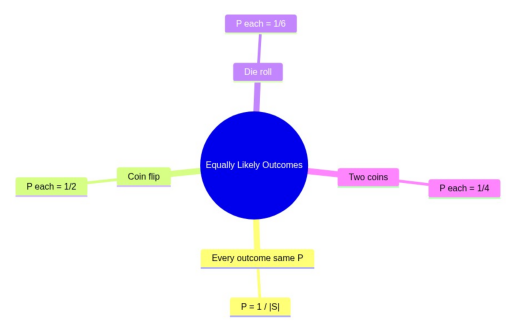

In [2]:
# Mermaid: Equally likely outcomes concept map
mm("""
mindmap
  root((Equally Likely Outcomes))
    Every outcome same P
      P = 1 / |S|
    Coin flip
      P each = 1/2
    Die roll
      P each = 1/6
    Two coins
      P each = 1/4
""")

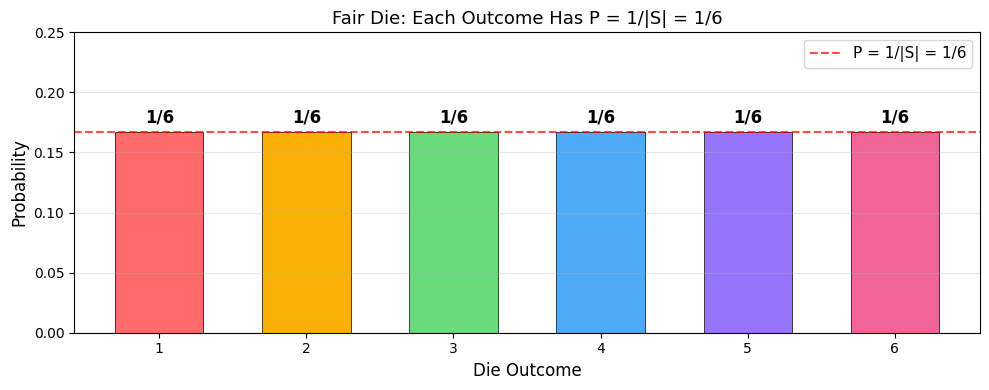

|S| = 6
P(each outcome) = 1/6 ≈ 0.1667


In [3]:
# Visualize: each outcome in a fair die has equal probability
S_die = {1, 2, 3, 4, 5, 6}
n_outcomes = len(S_die)

fig, ax = plt.subplots(figsize=(10, 4))
die_colors = ["#ff6b6b", "#fab005", "#69db7c", "#4dabf7", "#9775fa", "#f06595"]
probs = [1 / n_outcomes] * n_outcomes
bars = ax.bar([str(i) for i in range(1, 7)], probs, color=die_colors, edgecolor='black', linewidth=0.5, width=0.6)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"1/{n_outcomes}", ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=1/n_outcomes, color='red', linestyle='--', alpha=0.7, label=f'P = 1/|S| = 1/{n_outcomes}')
ax.set_xlabel("Die Outcome", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title(f"Fair Die: Each Outcome Has P = 1/|S| = 1/{n_outcomes}", fontsize=13)
ax.set_ylim(0, 0.25)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"|S| = {n_outcomes}")
print(f"P(each outcome) = 1/{n_outcomes} \u2248 {1/n_outcomes:.4f}")

---

## 2. The Equally Likely Outcome Rule

> **Definition:** If $S$ is a sample space with equally likely outcomes, for an event $E \subseteq S$:
>
> $$P(E) = \frac{|E|}{|S|} = \frac{\text{number of outcomes in } E}{\text{number of outcomes in } S}$$

This is extremely powerful — it reduces probability to **counting**.

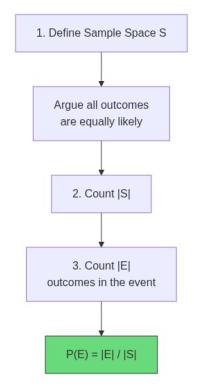

In [4]:
# Mermaid: The 3-step process
mm("""
graph TD
    A["1. Define Sample Space S"] --> B["Argue all outcomes<br/>are equally likely"]
    B --> C["2. Count |S|"]
    C --> D["3. Count |E|<br/>outcomes in the event"]
    D --> F["P(E) = |E| / |S|"]
    style F fill:#69db7c,stroke:#333
""")

Example: P(roll ≤ 3) on a fair die
  S = [1, 2, 3, 4, 5, 6]  →  |S| = 6
  E = [1, 2, 3]  →  |E| = 3
  P(E) = |E|/|S| = 3/6 = 0.5000


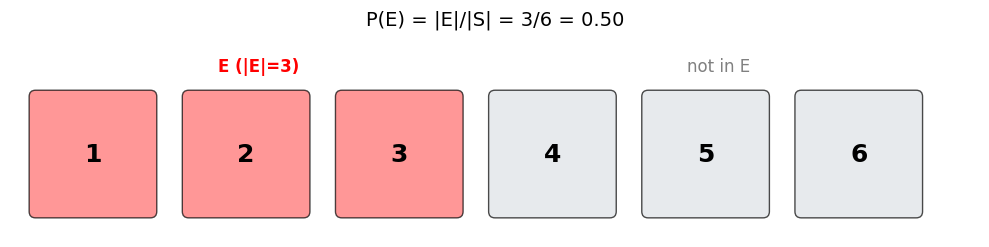

In [5]:
# Example: P(rolling a number <= 3 on a fair die)
S = {1, 2, 3, 4, 5, 6}
E = {1, 2, 3}

p = len(E) / len(S)

print("Example: P(roll \u2264 3) on a fair die")
print(f"  S = {sorted(S)}  \u2192  |S| = {len(S)}")
print(f"  E = {sorted(E)}  \u2192  |E| = {len(E)}")
print(f"  P(E) = |E|/|S| = {len(E)}/{len(S)} = {p:.4f}")

# Visualization: highlight event outcomes
fig, ax = plt.subplots(figsize=(10, 3))
for i, face in enumerate(range(1, 7)):
    in_event = face in E
    color = "#ff6b6b" if in_event else "#dee2e6"
    rect = patches.FancyBboxPatch((i * 1.2 + 0.1, 0.1), 0.9, 0.9,
                                   boxstyle="round,pad=0.05", facecolor=color, alpha=0.7, edgecolor='black')
    ax.add_patch(rect)
    ax.text(i * 1.2 + 0.55, 0.55, str(face), ha='center', va='center', fontsize=18, fontweight='bold')

ax.text(1.85, 1.2, f"E (|E|={len(E)})", ha='center', fontsize=12, color='red', fontweight='bold')
ax.text(5.45, 1.2, "not in E", ha='center', fontsize=12, color='gray')
ax.set_xlim(-0.1, 7.5)
ax.set_ylim(-0.1, 1.5)
ax.set_aspect('equal')
ax.set_title(f"P(E) = |E|/|S| = {len(E)}/{len(S)} = {p:.2f}", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

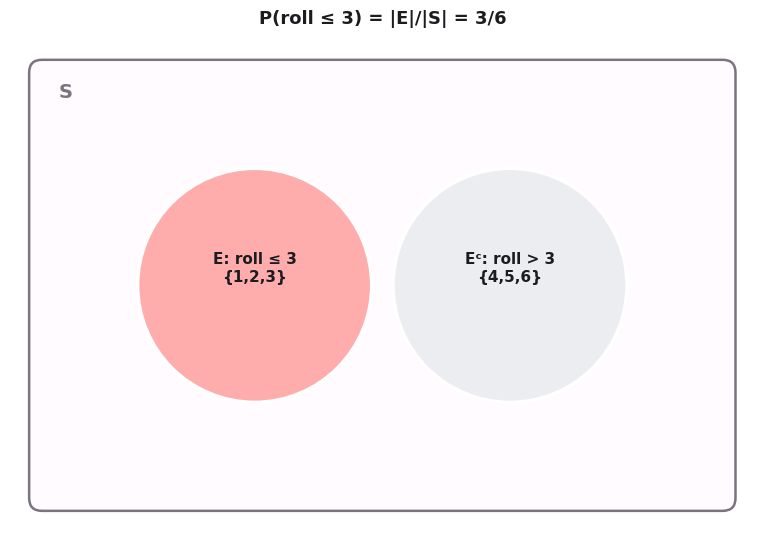

In [6]:
# Venn diagram: Event E within Sample Space S
venn("""
venn-beta
  title "P(roll \u2264 3) = |E|/|S| = 3/6"
  set E["E: roll \u2264 3<br/>{1,2,3}"]
  set Ec["E\u1d9c: roll > 3<br/>{4,5,6}"]
  style E fill:#ff6b6b
  style Ec fill:#dee2e6
""")

---

## 3. Example: Sum of Two Dice Equals 7

> **Problem:** What is the probability that the sum of two dice is equal to 7?

### Setting Up the Sample Space

We treat the two dice as **distinct** (die 1 and die 2). Each outcome is an ordered pair $(d_1, d_2)$.

- $|S| = 6 \times 6 = 36$ outcomes
- Each outcome is equally likely with probability $\frac{1}{36}$

**Warning:** Defining $S$ as the set of possible sums $\{2, 3, \ldots, 12\}$ would be **wrong** — those sums are NOT equally likely!

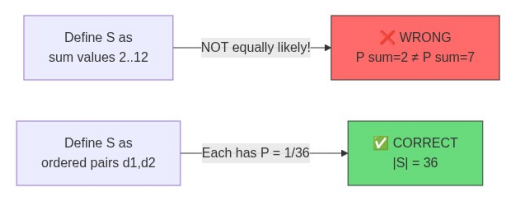

In [7]:
# Mermaid: Why distinct dice matter
mm("""
graph LR
    A["Define S as<br/>sum values 2..12"] -->|"NOT equally likely!"| B["\u274c WRONG<br/>P sum=2 \u2260 P sum=7"]
    C["Define S as<br/>ordered pairs d1,d2"] -->|"Each has P = 1/36"| D["\u2705 CORRECT<br/>|S| = 36"]
    style B fill:#ff6b6b,stroke:#333
    style D fill:#69db7c,stroke:#333
""")

|S| = 36 outcomes



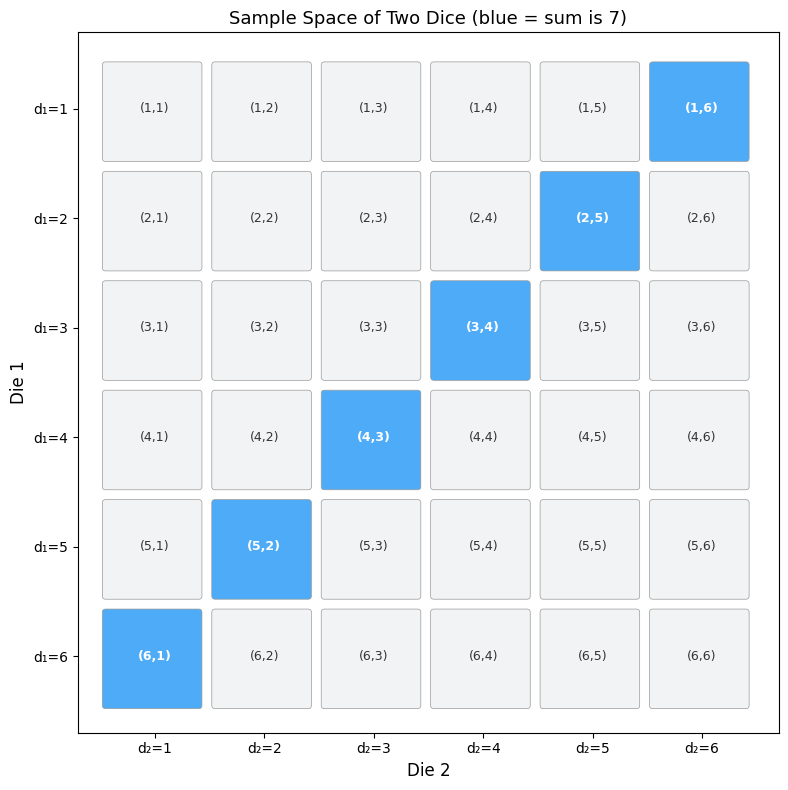

Event E (sum = 7): [(1, 6), (2, 5), (3, 4), (4, 3), (5, 2), (6, 1)]
|E| = 6
|S| = 36
P(sum = 7) = |E|/|S| = 6/36 = 0.1667


In [8]:
# Build the full sample space of two distinct dice
S_two_dice = [(d1, d2) for d1 in range(1, 7) for d2 in range(1, 7)]
print(f"|S| = {len(S_two_dice)} outcomes\n")

# Visualize the 6x6 grid - highlight outcomes where sum = 7
E_sum7 = [(d1, d2) for d1, d2 in S_two_dice if d1 + d2 == 7]
E_sum7_set = set(E_sum7)

fig, ax = plt.subplots(figsize=(8, 8))

for d1 in range(1, 7):
    for d2 in range(1, 7):
        in_event = (d1, d2) in E_sum7_set
        color = "#4dabf7" if in_event else "#f1f3f5"
        rect = patches.FancyBboxPatch((d2 - 0.45, 7 - d1 - 0.45), 0.85, 0.85,
                                       boxstyle="round,pad=0.03", facecolor=color,
                                       edgecolor='#999', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(d2, 7 - d1, f"({d1},{d2})", ha='center', va='center',
                fontsize=9, fontweight='bold' if in_event else 'normal',
                color='white' if in_event else '#333')

ax.set_xlim(0.3, 6.7)
ax.set_ylim(0.3, 6.7)
ax.set_xticks(range(1, 7))
ax.set_yticks(range(1, 7))
ax.set_xticklabels([f"d\u2082={i}" for i in range(1, 7)], fontsize=10)
ax.set_yticklabels([f"d\u2081={i}" for i in range(6, 0, -1)], fontsize=10)
ax.set_xlabel("Die 2", fontsize=12)
ax.set_ylabel("Die 1", fontsize=12)
ax.set_title("Sample Space of Two Dice (blue = sum is 7)", fontsize=13)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

print(f"Event E (sum = 7): {E_sum7}")
print(f"|E| = {len(E_sum7)}")
print(f"|S| = {len(S_two_dice)}")
print(f"P(sum = 7) = |E|/|S| = {len(E_sum7)}/{len(S_two_dice)} = {len(E_sum7)/len(S_two_dice):.4f}")

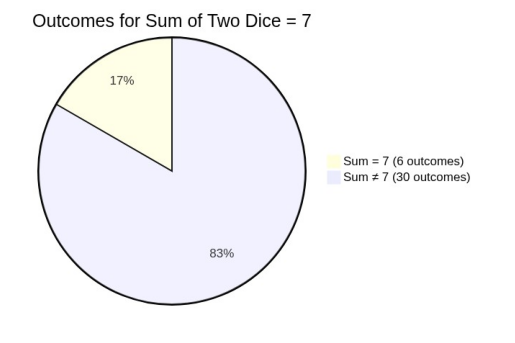

In [9]:
# Mermaid: Pie chart - 6 favorable out of 36
mm("""
pie title Outcomes for Sum of Two Dice = 7
    "Sum = 7 (6 outcomes)" : 6
    "Sum \u2260 7 (30 outcomes)" : 30
""")

### Why Sums Are NOT Equally Likely

If we naively define $S = \{2, 3, \ldots, 12\}$, the outcomes are **not** equally likely because different sums can be formed in different numbers of ways.

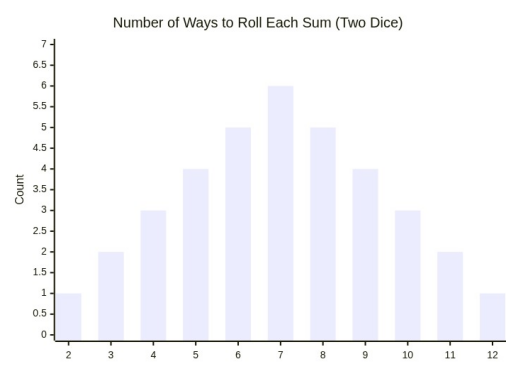

In [10]:
# Count how many ways each sum can be formed
sum_counts = Counter(d1 + d2 for d1, d2 in S_two_dice)
sums = list(range(2, 13))
counts = [sum_counts[s] for s in sums]
probs_sum = [c / 36 for c in counts]

# Mermaid: bar chart of sum counts
x_labels = ', '.join([f'"{s}"' for s in sums])
y_values = ', '.join([str(c) for c in counts])
mm(f"""
xychart-beta
    title "Number of Ways to Roll Each Sum (Two Dice)"
    x-axis [{x_labels}]
    y-axis "Count" 0 --> 7
    bar [{y_values}]
""")

In [11]:
# Show the counts and probabilities in detail
print("Sum | # Ways | P(sum)")
print("\u2500" * 30)
for s, c, p in zip(sums, counts, probs_sum):
    marker = " \u25c4\u2500\u2500 sum=7" if s == 7 else ""
    print(f" {s:2d}  |   {c}    | {p:.4f}{marker}")

print(f"\nTotal ways: {sum(counts)} = 36  \u2713")

Sum | # Ways | P(sum)
──────────────────────────────
  2  |   1    | 0.0278
  3  |   2    | 0.0556
  4  |   3    | 0.0833
  5  |   4    | 0.1111
  6  |   5    | 0.1389
  7  |   6    | 0.1667 ◄── sum=7
  8  |   5    | 0.1389
  9  |   4    | 0.1111
 10  |   3    | 0.0833
 11  |   2    | 0.0556
 12  |   1    | 0.0278

Total ways: 36 = 36  ✓


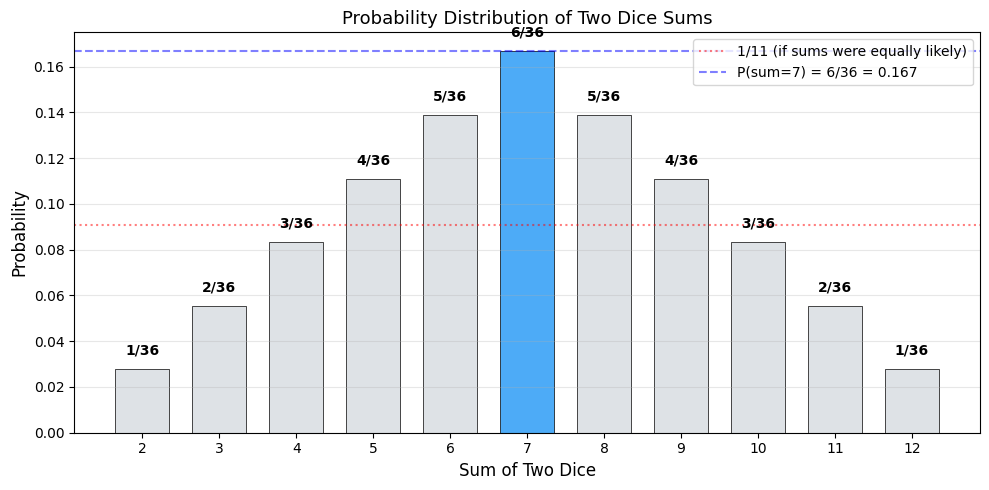

In [12]:
# Matplotlib: detailed probability distribution with annotations
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4dabf7' if s == 7 else '#dee2e6' for s in sums]
bars = ax.bar([str(s) for s in sums], probs_sum, color=colors, edgecolor='black', linewidth=0.5, width=0.7)

for bar, c, p in zip(bars, counts, probs_sum):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{c}/36", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=1/11, color='red', linestyle=':', alpha=0.5, label='1/11 (if sums were equally likely)')
ax.axhline(y=6/36, color='blue', linestyle='--', alpha=0.5, label=f'P(sum=7) = 6/36 = {6/36:.3f}')
ax.set_xlabel("Sum of Two Dice", fontsize=12)
ax.set_ylabel("Probability", fontsize=12)
ax.set_title("Probability Distribution of Two Dice Sums", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Simulation Verification

Let's verify $P(\text{sum} = 7) = \frac{6}{36} = \frac{1}{6}$ by simulation.

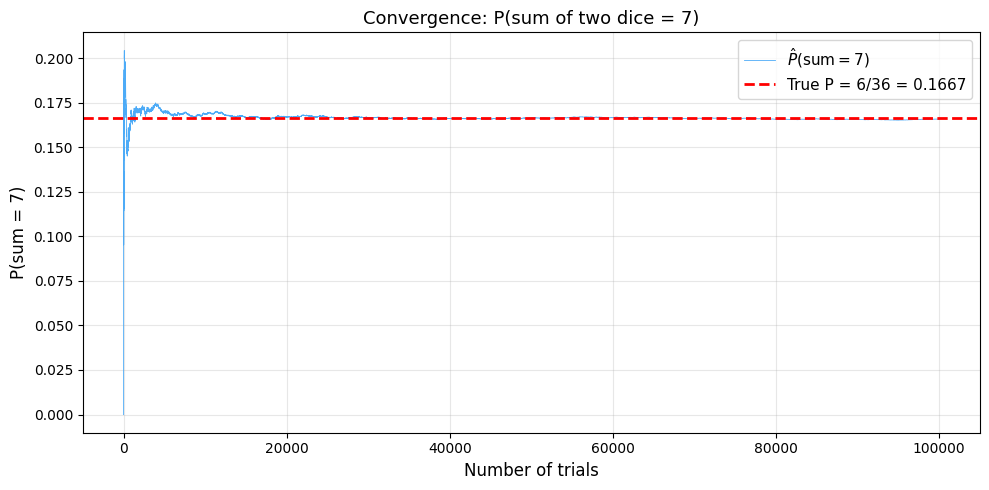

After 100,000 simulations: P(sum=7) ≈ 0.1657
True probability:                P(sum=7) = 0.1667


In [13]:
# Simulate rolling two dice many times
n_simulations = 100_000
die1 = np.random.randint(1, 7, size=n_simulations)
die2 = np.random.randint(1, 7, size=n_simulations)
sums_sim = die1 + die2

event_sum7 = sums_sim == 7
cumsum7 = np.cumsum(event_sum7)
trials = np.arange(1, n_simulations + 1)
running_p = cumsum7 / trials
true_p = 6 / 36

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trials, running_p, linewidth=0.6, color='#4dabf7', label=r'$\hat{P}(\mathrm{sum}=7)$')
ax.axhline(y=true_p, color='red', linestyle='--', linewidth=2, label=f'True P = 6/36 = {true_p:.4f}')
ax.set_xlabel("Number of trials", fontsize=12)
ax.set_ylabel("P(sum = 7)", fontsize=12)
ax.set_title("Convergence: P(sum of two dice = 7)", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"After {n_simulations:,} simulations: P(sum=7) \u2248 {running_p[-1]:.4f}")
print(f"True probability:                P(sum=7) = {true_p:.4f}")

---

## 4. More Examples

### Example: At Least One Head in Two Coin Flips

$S = \{(H,H), (H,T), (T,H), (T,T)\}$, all equally likely.

$E = \{(H,H), (H,T), (T,H)\}$ — at least one head.

$$P(E) = \frac{|E|}{|S|} = \frac{3}{4}$$

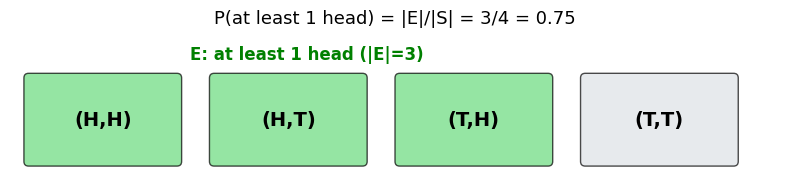

In [14]:
# Visualize two coin flip outcomes
S_coins = [("H","H"), ("H","T"), ("T","H"), ("T","T")]
E_coins = {("H","H"), ("H","T"), ("T","H")}

fig, ax = plt.subplots(figsize=(8, 3))
for i, (c1, c2) in enumerate(S_coins):
    in_event = (c1, c2) in E_coins
    color = "#69db7c" if in_event else "#dee2e6"
    rect = patches.FancyBboxPatch((i * 2.0 + 0.1, 0.1), 1.6, 0.9,
                                   boxstyle="round,pad=0.05", facecolor=color,
                                   alpha=0.7, edgecolor='black')
    ax.add_patch(rect)
    ax.text(i * 2.0 + 0.9, 0.55, f"({c1},{c2})", ha='center', va='center',
            fontsize=14, fontweight='bold')

ax.text(3.1, 1.2, f"E: at least 1 head (|E|={len(E_coins)})", ha='center',
        fontsize=12, color='green', fontweight='bold')
ax.set_xlim(-0.1, 8.2)
ax.set_ylim(-0.1, 1.5)
ax.set_aspect('equal')
ax.set_title(f"P(at least 1 head) = |E|/|S| = {len(E_coins)}/{len(S_coins)} = {len(E_coins)/len(S_coins):.2f}",
             fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

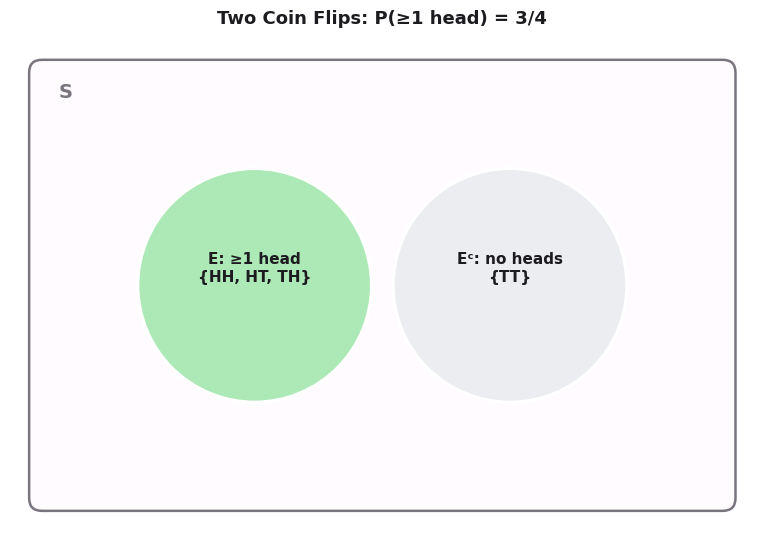

In [15]:
# Venn: Event vs Complement for coin flips
venn("""
venn-beta
  title "Two Coin Flips: P(\u22651 head) = 3/4"
  set E["E: \u22651 head<br/>{HH, HT, TH}"]
  set Ec["E\u1d9c: no heads<br/>{TT}"]
  style E fill:#69db7c
  style Ec fill:#dee2e6
""")

### Example: Drawing a Heart from a Deck of Cards

Standard deck: 52 cards, 13 hearts.

$$P(\text{Heart}) = \frac{|E|}{|S|} = \frac{13}{52} = \frac{1}{4}$$

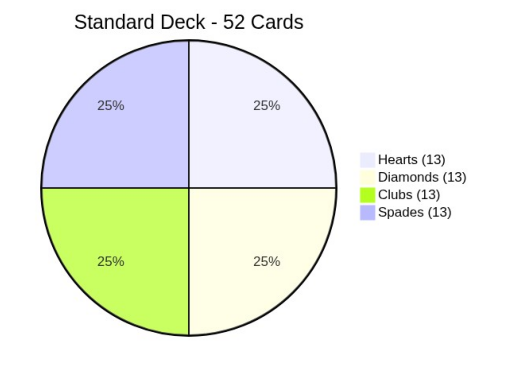

In [16]:
# Mermaid: Deck of cards breakdown
mm("""
pie title Standard Deck - 52 Cards
    "Hearts (13)" : 13
    "Diamonds (13)" : 13
    "Clubs (13)" : 13
    "Spades (13)" : 13
""")

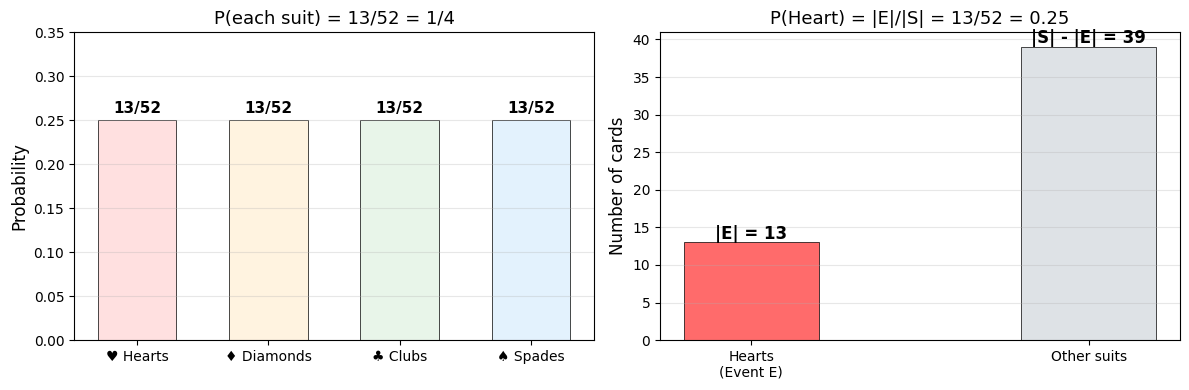

P(drawing a heart) = 13/52 = 0.2500


In [17]:
# Compute and visualize
S_deck = 52
E_hearts = 13
p_heart = E_hearts / S_deck

suits = ["\u2665 Hearts", "\u2666 Diamonds", "\u2663 Clubs", "\u2660 Spades"]
bg_colors = ["#ffe0e0", "#fff3e0", "#e8f5e9", "#e3f2fd"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart: P(each suit) = 1/4
bars = ax1.bar(suits, [1/4]*4, color=bg_colors, edgecolor='black', linewidth=0.5, width=0.6)
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             "13/52", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylabel("Probability", fontsize=12)
ax1.set_title("P(each suit) = 13/52 = 1/4", fontsize=13)
ax1.set_ylim(0, 0.35)
ax1.grid(axis='y', alpha=0.3)

# Highlight hearts
ax2.bar(["Hearts\n(Event E)"], [E_hearts], color='#ff6b6b', edgecolor='black', linewidth=0.5, width=0.4)
ax2.bar(["Other suits"], [S_deck - E_hearts], color='#dee2e6', edgecolor='black', linewidth=0.5, width=0.4)
ax2.text(0, E_hearts + 0.5, f"|E| = {E_hearts}", ha='center', fontsize=12, fontweight='bold')
ax2.text(1, (S_deck - E_hearts) + 0.5, f"|S| - |E| = {S_deck - E_hearts}", ha='center', fontsize=12, fontweight='bold')
ax2.set_ylabel("Number of cards", fontsize=12)
ax2.set_title(f"P(Heart) = |E|/|S| = {E_hearts}/{S_deck} = {p_heart:.2f}", fontsize=13)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"P(drawing a heart) = {E_hearts}/{S_deck} = {p_heart:.4f}")

---

## 5. Continuous Equally Likely Outcomes

The equally likely rule extends to **continuous** sample spaces.

> Consider the function `random()` that produces a real number uniformly in $[0, 1]$.
> All values are equally likely.
>
> **Event $E$:** The number is in the range $[0.3, 0.7]$.
>
> $$P(E) = \frac{\text{size of } E}{\text{size of } S} = \frac{0.7 - 0.3}{1 - 0} = 0.4$$

The "size" here is the **length** of the interval (for 1D), area (for 2D), etc.

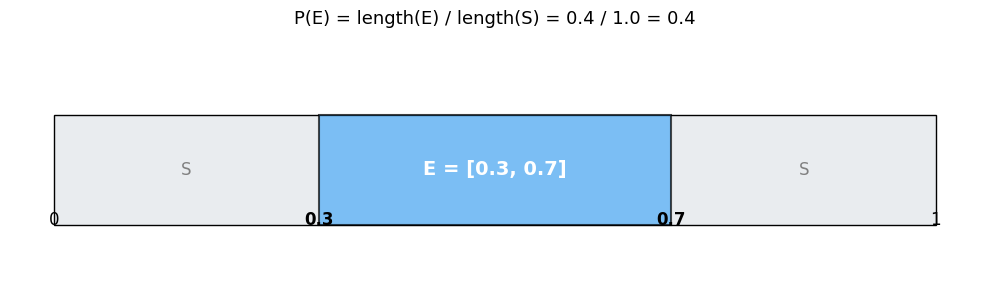

In [18]:
# Visualize the continuous uniform sample space
fig, ax = plt.subplots(figsize=(10, 3))

# Full sample space [0, 1]
ax.barh(0, 1, left=0, height=0.4, color='#e9ecef', edgecolor='black', linewidth=1)
# Event E = [0.3, 0.7]
ax.barh(0, 0.4, left=0.3, height=0.4, color='#4dabf7', edgecolor='black', linewidth=1.5, alpha=0.7)

ax.text(0.5, 0, "E = [0.3, 0.7]", ha='center', va='center', fontsize=14, fontweight='bold', color='white')
ax.text(0.15, 0, "S", ha='center', va='center', fontsize=12, color='gray')
ax.text(0.85, 0, "S", ha='center', va='center', fontsize=12, color='gray')

# Annotations
ax.annotate('0.3', xy=(0.3, -0.2), fontsize=12, ha='center', fontweight='bold')
ax.annotate('0.7', xy=(0.7, -0.2), fontsize=12, ha='center', fontweight='bold')
ax.annotate('0', xy=(0, -0.2), fontsize=12, ha='center')
ax.annotate('1', xy=(1, -0.2), fontsize=12, ha='center')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.4, 0.5)
ax.set_title("P(E) = length(E) / length(S) = 0.4 / 1.0 = 0.4", fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

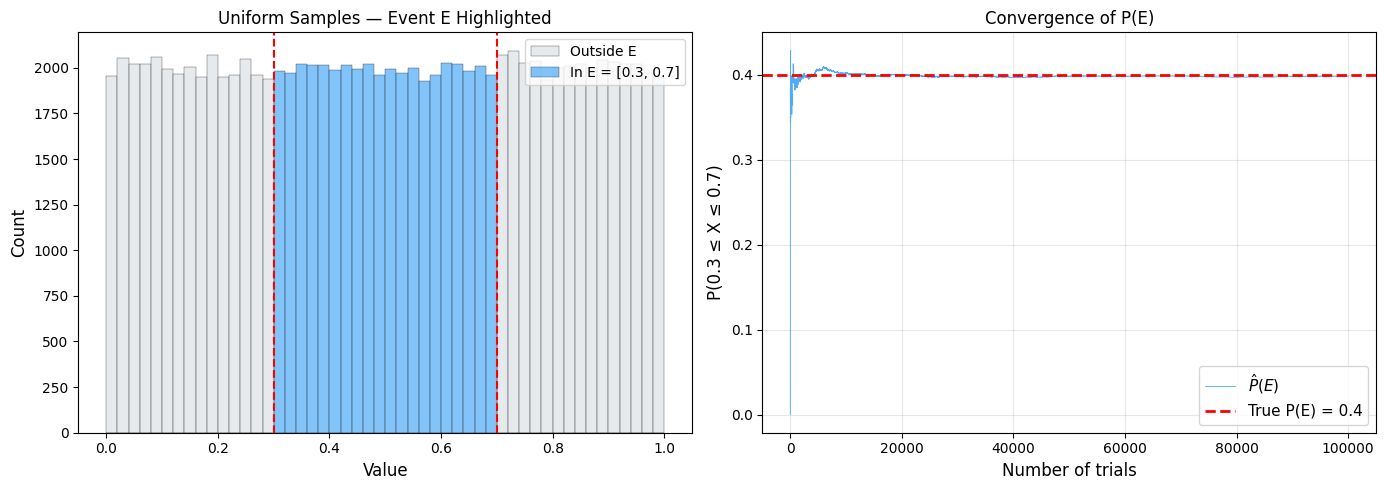

Analytical: P(E) = 0.4
Simulated:  P(E) ≈ 0.3984  (100,000 trials)


In [19]:
# Simulation: verify P(0.3 <= X <= 0.7) ~ 0.4
n_sim = 100_000
samples = np.random.uniform(0, 1, size=n_sim)
in_event = (samples >= 0.3) & (samples <= 0.7)
p_sim = np.mean(in_event)
p_true = 0.4

# Convergence
cumsum_e = np.cumsum(in_event)
trial_nums = np.arange(1, n_sim + 1)
running_p = cumsum_e / trial_nums

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of samples with event highlighted
ax1.hist(samples[~in_event], bins=50, range=(0, 1), color='#dee2e6', edgecolor='black',
         linewidth=0.3, alpha=0.7, label='Outside E')
ax1.hist(samples[in_event], bins=50, range=(0, 1), color='#4dabf7', edgecolor='black',
         linewidth=0.3, alpha=0.7, label='In E = [0.3, 0.7]')
ax1.axvline(x=0.3, color='red', linestyle='--', linewidth=1.5)
ax1.axvline(x=0.7, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel("Value", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Uniform Samples \u2014 Event E Highlighted", fontsize=12)
ax1.legend(fontsize=10)

# Convergence
ax2.plot(trial_nums, running_p, linewidth=0.6, color='#4dabf7', label=r'$\hat{P}(E)$')
ax2.axhline(y=p_true, color='red', linestyle='--', linewidth=2, label=f'True P(E) = {p_true}')
ax2.set_xlabel("Number of trials", fontsize=12)
ax2.set_ylabel("P(0.3 \u2264 X \u2264 0.7)", fontsize=12)
ax2.set_title("Convergence of P(E)", fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Analytical: P(E) = {p_true}")
print(f"Simulated:  P(E) \u2248 {p_sim:.4f}  ({n_sim:,} trials)")

---

## 6. The Art of Setting Up Equally Likely Problems

There is an **art form** to applying the equally likely outcome rule:

1. **Define your sample space** $S$ and argue all outcomes are equally likely
2. **Count $|S|$** — total number of outcomes
3. **Count $|E|$** — number of outcomes in the event

The first step gives you freedom — you can make indistinguishable objects distinct, as long as your count of $|E|$ uses the **same assumptions**.

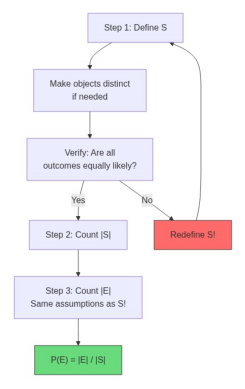

In [20]:
# Mermaid: The art of setting up problems
mm("""
graph TD
    A["Step 1: Define S"] --> A1["Make objects distinct<br/>if needed"]
    A1 --> A2["Verify: Are all<br/>outcomes equally likely?"]
    A2 -->|Yes| B["Step 2: Count |S|"]
    A2 -->|No| A3["Redefine S!"]
    A3 --> A
    B --> C["Step 3: Count |E|<br/>Same assumptions as S!"]
    C --> D["P(E) = |E| / |S|"]
    style A3 fill:#ff6b6b,stroke:#333
    style D fill:#69db7c,stroke:#333
""")

### Common Pitfall: Non-Equally-Likely Sample Spaces

| Sample Space | Equally Likely? | Why? |
|---|---|---|
| Ordered dice pairs $(d_1, d_2)$, $\lvert S \rvert = 36$ | \u2705 Yes | Each pair has $P = 1/36$ |
| Sum values $\{2, \ldots, 12\}$, $\lvert S \rvert = 11$ | \u274c No | Sum=7 has 6 ways, Sum=2 has 1 way |
| Coin flip $\{H, T\}$ | \u2705 Yes | Fair coin |
| Weather $\{\text{Rain, No Rain}\}$ | \u274c No | Not equally likely in general |

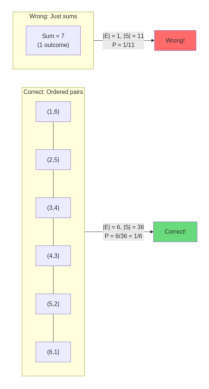

In [21]:
# Mermaid: Comparison of correct vs incorrect sample space
mm("""
graph LR
    subgraph Correct["Correct: Ordered pairs"]
        C1["(1,6)"] --- C2["(2,5)"]
        C2 --- C3["(3,4)"]
        C3 --- C4["(4,3)"]
        C4 --- C5["(5,2)"]
        C5 --- C6["(6,1)"]
    end
    subgraph Wrong["Wrong: Just sums"]
        W1["Sum = 7<br/>(1 outcome)"]
    end
    Correct -->|"|E| = 6, |S| = 36<br/>P = 6/36 = 1/6"| R1["Correct!"]
    Wrong -->|"|E| = 1, |S| = 11<br/>P = 1/11"| R2["Wrong!"]
    style R1 fill:#69db7c
    style R2 fill:#ff6b6b
""")

---

## Summary

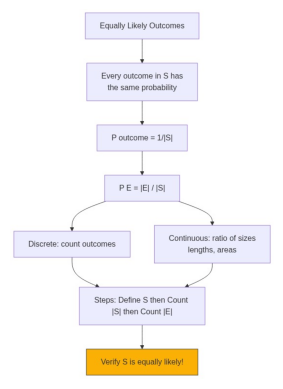

In [22]:
# Summary flowchart
mm("""
graph TD
    A["Equally Likely Outcomes"] --> B["Every outcome in S has<br/>the same probability"]
    B --> C["P outcome = 1/|S|"]
    C --> D["P E = |E| / |S|"]
    D --> E1["Discrete: count outcomes"]
    D --> E2["Continuous: ratio of sizes<br/>lengths, areas"]
    E1 --> F["Steps: Define S then Count |S| then Count |E|"]
    E2 --> F
    F --> G["Verify S is equally likely!"]
    style G fill:#fab005,stroke:#333
""")

| Concept | Formula |
|---|---|
| Equally likely outcome probability | $P(\text{outcome}) = \frac{1}{\lvert S \rvert}$ |
| Event probability | $P(E) = \frac{\lvert E \rvert}{\lvert S \rvert}$ |
| Continuous case | $P(E) = \frac{\text{size}(E)}{\text{size}(S)}$ |
| Two dice, sum = 7 | $P = \frac{6}{36} = \frac{1}{6}$ |